In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [26]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [27]:
df.shape

(1338, 7)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [29]:
print("Missing Values:\n",df.isnull().sum())
print("\nDescriptive Statistics:\n",df.describe())
print("\nData Info:\n",df.info())
for col in ['sex', 'smoker', 'region']:
    print(f"\nUnique values in '{col}':\n", df[col].unique())

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Descriptive Statistics:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children 

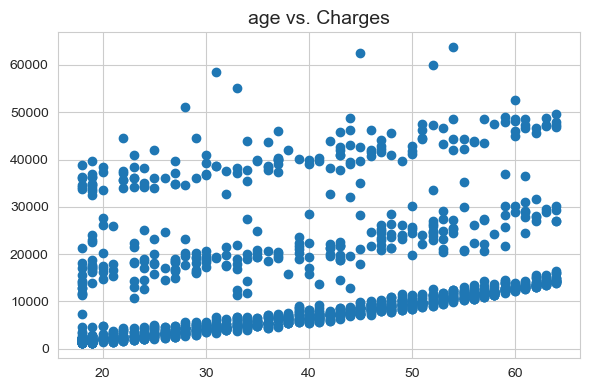

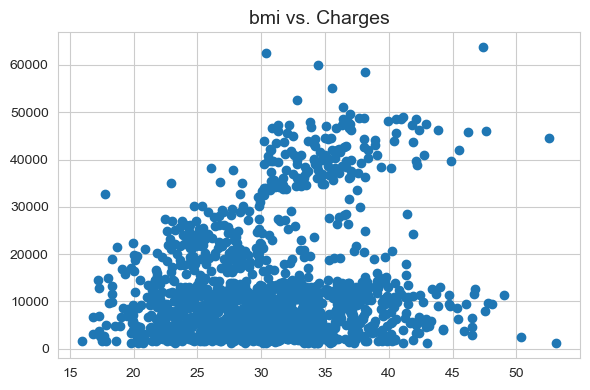

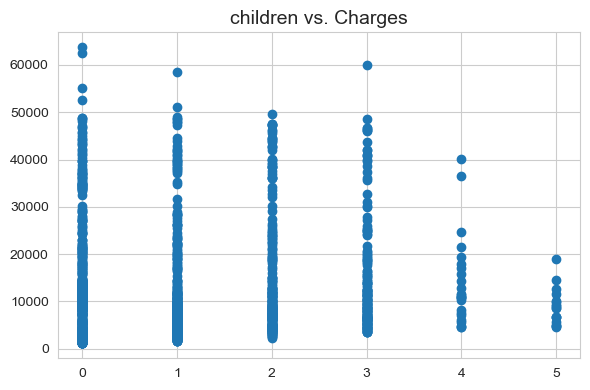

In [30]:
for col in ['age','bmi','children']:
    plt.figure(figsize=(6,4))
    plt.scatter(x = col, y = 'charges',data = df)
    plt.title(f"{col} vs. Charges",fontsize = 14)
    plt.tight_layout()
    plt.show()

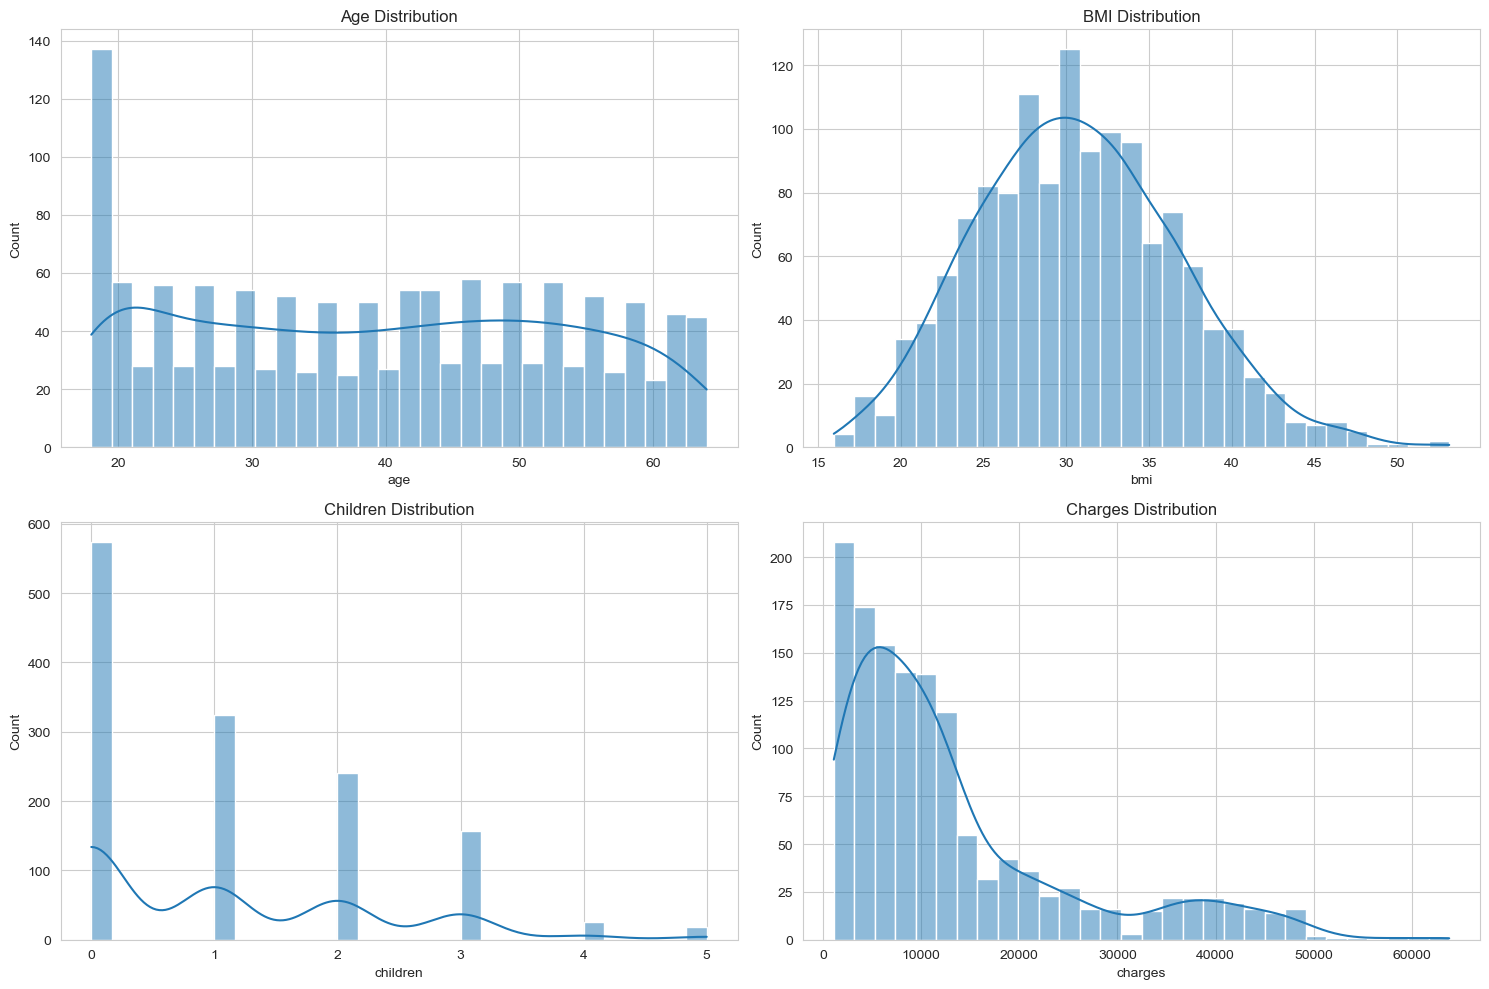

In [31]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(2,2,figsize = (15,10))

sns.histplot(df['age'],bins = 30,kde = True, ax = ax[0,0])
ax[0,0].set_title("Age Distribution")

sns.histplot(df['bmi'],bins = 30,kde = True, ax = ax[0,1])
ax[0,1].set_title("BMI Distribution")

sns.histplot(df['children'],bins = 30,kde = True, ax = ax[1,0])
ax[1,0].set_title("Children Distribution")

sns.histplot(df['charges'],bins = 30,kde = True, ax = ax[1,1])
ax[1,1].set_title("Charges Distribution")

plt.tight_layout()
plt.show()

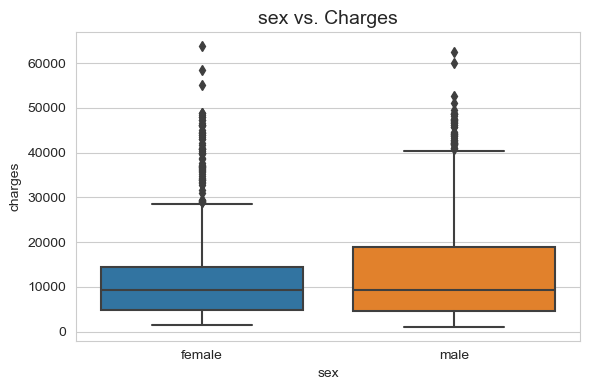

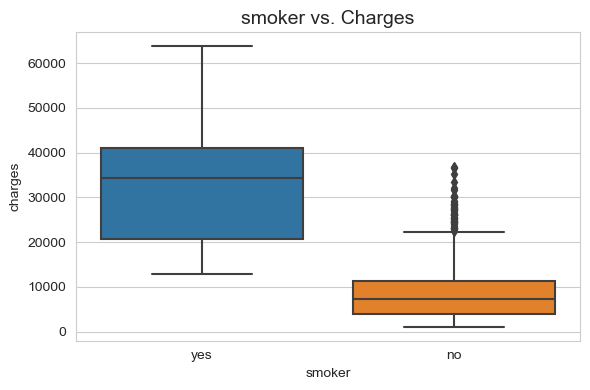

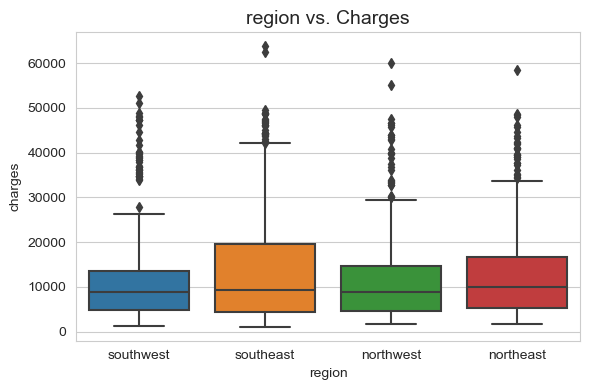

In [32]:
for col in ['sex', 'smoker', 'region']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=col, y='charges', data=df)
    plt.title(f"{col} vs. Charges", fontsize=14)
    plt.tight_layout()
    plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_3988\1562739956.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_with_charges = df.corr()['charges'].drop('charges')


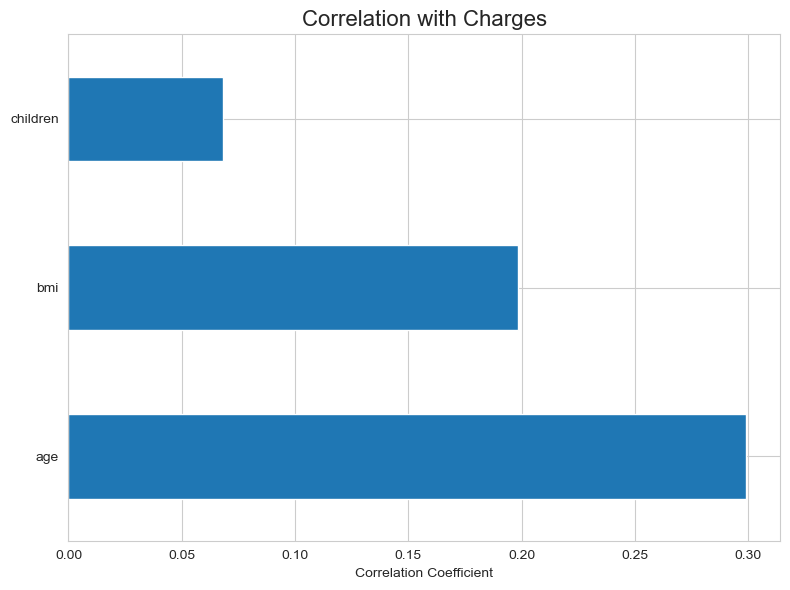

In [33]:
correlation_with_charges = df.corr()['charges'].drop('charges')
plt.figure(figsize = (8,6))
correlation_with_charges.plot(kind = 'barh')
plt.title("Correlation with Charges",fontsize = 16)
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

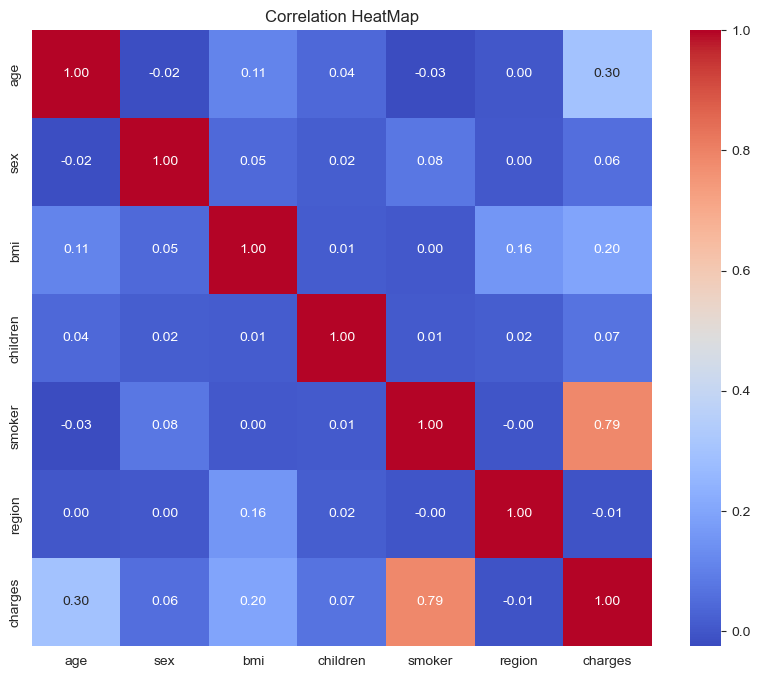

In [34]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

df['region'] = label_encoder.fit_transform(df['region'])

correlation_matrix = df.corr()
plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix,annot = True,cmap = 'coolwarm',fmt = '.2f')
plt.title("Correlation HeatMap")
plt.show()

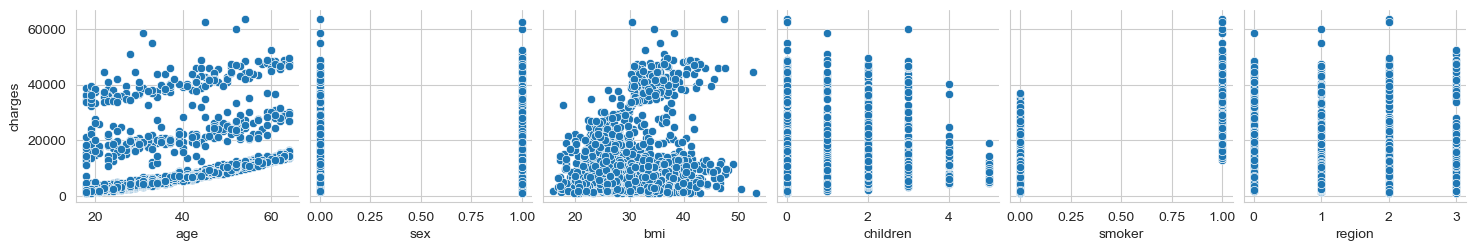

In [35]:
sns.pairplot(df, x_vars=['age', 'sex', 'bmi', 'children', 'smoker', 'region'], y_vars=['charges'], kind='scatter')
plt.show()

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

X = df.drop('charges',axis = 1)
y = df['charges']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Mean squared error: {mse}")
print(f"R-squared: {r2}")

Mean squared error: 33635210.43117841
R-squared: 0.7833463107364538


In [37]:
comparision_df = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})

print("Comparision of Actual and Predicted Values\n")
print(comparision_df)

Comparision of Actual and Predicted Values

           Actual     Predicted
764    9095.06825   8924.407244
887    5272.17580   7116.295018
890   29330.98315  36909.013521
1293   9301.89355   9507.874691
259   33750.29180  27013.350008
...           ...           ...
109   47055.53210  39116.968669
575   12222.89830  11814.555568
535    6067.12675   7638.107736
543   63770.42801  40959.081722
846    9872.70100  12258.228529

[268 rows x 2 columns]


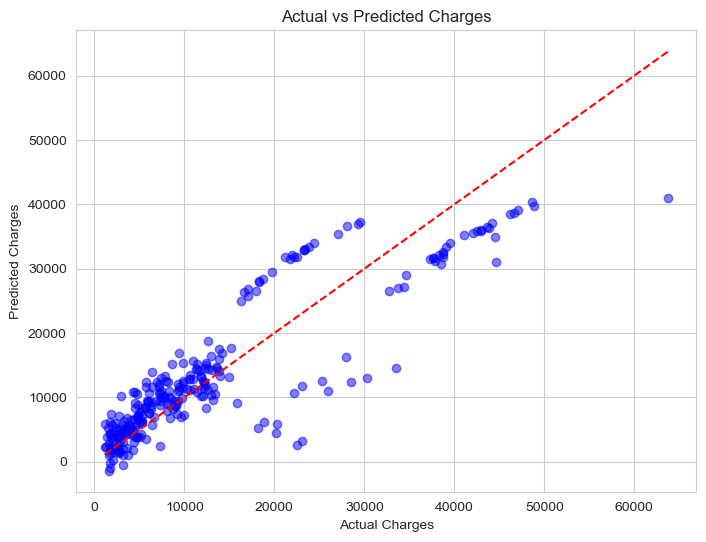

In [39]:
plt.figure(figsize = (8,6))
plt.scatter(y_test,y_pred,color = 'blue',alpha = 0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color = 'red',linestyle = '--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()